# Kaggle - Binary Prediction of Poisonous Mushrooms

## Competition Context
This competition is part of the Tabular Playground Series (S4E8).
The goal is to predict the class of a mushroom from its physical characteristics.

## Prediction Objective
For each observation in the test set, we want to predict the target variable `class`:
- `e`: edible
- `p`: poisonous

This is a **binary classification** problem.

## Dataset Analysis

In this section, we aim to understand the structure and quality of the dataset before modeling.

In [19]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent

train_path = ROOT / "data" / "train.csv"
test_path = ROOT / "data" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"Train file  : {train_path}")
print(f"Test file   : {test_path}")

Train shape: (3116945, 22)
Test shape : (2077964, 21)
Train file  : c:\Users\Antoine\Documents\UTBM\DS52\MushroomPrediction\mushroom-prediction\data\train.csv
Test file   : c:\Users\Antoine\Documents\UTBM\DS52\MushroomPrediction\mushroom-prediction\data\test.csv


The train set has 3 116 945 entries, and 22 features (including the label)

The test set has 2 077 964 entries, and 21 features

In [2]:
train_df.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,4.51,15.39,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,4.79,6.48,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,6.85,9.93,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,4.16,6.53,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,3.37,8.36,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


By looking at the first few rows of the train dataset, wd can see what it looks like.

We notice that some columns already have NaN values on these first few rows. 

## 1) Data Inventory

Questions to answer:
- How many rows and columns are in train and test?
- Which columns are categorical, numerical, or mixed?
- Is there any identifier column that should not be used as a feature?


In [3]:
train_feature_cols = [c for c in train_df.columns if c != "class"]

def describe_columns(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append(
            {
                "dataset": name,
                "column": col,
                "dtype": str(s.dtype),
                "n_unique": s.nunique(dropna=True),
                "missing_pct": round(s.isna().mean() * 100, 2),
                "kind": (
                    "identifier" if col.lower() == "id"
                    else "target" if col == "class"
                    else "categorical" if s.dtype == "object"
                    else "numeric"
                ),
            }
        )
    return pd.DataFrame(rows)

inventory = pd.concat(
    [describe_columns(train_df, "train"), describe_columns(test_df, "test")],
    ignore_index=True,
)

shape_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "columns": [train_df.shape[1], test_df.shape[1]],
    }
)

print("Dataset shape summary:")
display(shape_summary)

print("Column-level inventory (first 20 rows):")
display(inventory.head(20))

print("Feature dtype distribution (train, excluding target):")
display(train_df[train_feature_cols].dtypes.value_counts().rename_axis("dtype").reset_index(name="count"))

Dataset shape summary:


,dataset,rows,columns
0,train,3116945,22
1,test,2077964,21


Column-level inventory (first 20 rows):


,dataset,column,dtype,n_unique,missing_pct,kind
0,train,id,int64,3116945,0.00,identifier
1,train,class,str,2,0.00,target
2,train,cap-diameter,float64,3913,0.00,numeric
3,train,cap-shape,str,74,0.00,numeric
4,train,cap-surface,str,83,21.53,numeric
5,train,cap-color,str,78,0.00,numeric
6,train,does-bruise-or-bleed,str,26,0.00,numeric
7,train,gill-attachment,str,78,16.81,numeric
8,train,gill-spacing,str,48,40.37,numeric
9,train,gill-color,str,63,0.00,numeric


Feature dtype distribution (train, excluding target):


,dtype,count
0,str,17
1,float64,3
2,int64,1


### Interpretation

We use this output to answer these questions:
- What is the role of each column (identifier, target, categorical, numerical)?
- Are there obvious data quality risks (high missing rate, unusual type)?
- Which transformations will be required before modeling?

We have a lot of columns that have a type string, and only a few with floats and integers.

Some columns are missing a lot of values, and need to be handled properly in consequence :


veil-type - 94.88% of missing values

spore-print-color - 91.43%

stem-root - 88.45%

veil-color - 87.94%

stem-surface - 63.55%

gill-spacing - 40.37%

cap-surface - 21.53%

gill-attachment - 16.81%

ring-type - 4.13%


We also have many features that have many unique values

If we look at the feature veil-type in detail, here is what it looks like :

In [4]:
print("Unique values for 'veil-type' column:")
display(train_df['veil-type'].value_counts(dropna=False).to_frame())

Unique values for 'veil-type' column:


,count
veil-type,
NaN,2957493
u,159373
w,11
a,9
e,8
f,8
c,5
b,5
g,4


We have a majority of NaN values, followed by a large number of "u" values. The other values are present only with a few instances, making us believe there might be outliers here. The numbers are obviously outliers

Many of the categorical features have many unique values. We also need to check if it is right. For example, the feature cap-surface with 83 uniques values : 

In [5]:
print("Unique values for 'cap-surface' column:")
display(train_df['cap-surface'].value_counts(dropna=False).to_frame())

Unique values for 'cap-surface' column:


,count
cap-surface,
NaN,671023
t,460777
s,384970
y,327826
h,284460
g,263729
d,206832
k,128875
e,119712


This feature needs some analysis to see what is right or not. Indeed, we have a lot of different values : Many NaN values, followed by letters. Then there are some values that are the names of other features, which seems wrong, as well as numbers, which also seems wrong

## 2) Target Variable Analysis (`class`)

Questions to answer:
- Is the target balanced or imbalanced?
- What is the proportion of `e` vs `p`?

,count,percent
class,,
p,1705396,54.71
e,1411549,45.29


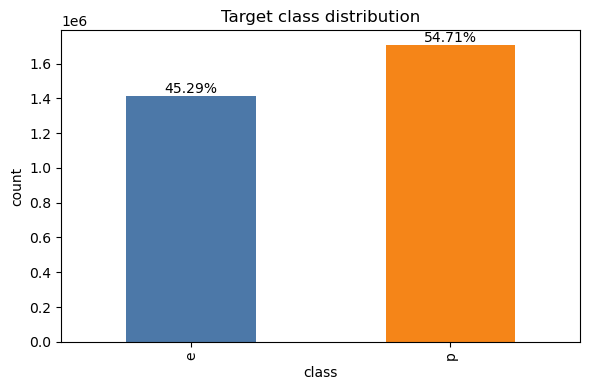

Imbalance ratio (majority/minority): 1.208


In [6]:
if "class" not in train_df.columns:
    raise ValueError("Column 'class' was not found in train.csv")

target_counts = train_df["class"].value_counts(dropna=False)
target_pct = train_df["class"].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({"count": target_counts, "percent": target_pct})
display(target_summary)

ax = target_counts.sort_index().plot(kind="bar", figsize=(6, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Target class distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")

for i, (label, value) in enumerate(target_counts.sort_index().items()):
    pct = target_pct[label]
    ax.text(i, value, f"{pct}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

balance_ratio = target_counts.max() / target_counts.min()
print(f"Imbalance ratio (majority/minority): {balance_ratio:.3f}")

### Interpretation :
We have a small difference distribution between the two classes. For the moment, we decide to stay with this proportion. But it can be an idea to adjust this proportion to improve the future model.

## 3) Missing Values and Data Quality

Questions to answer:
- Which columns contain missing values?
- What is the missing rate per column?
- Are there suspicious categories (typos, rare values, inconsistent labels)?

Columns with missing values: 18


,missing_pct_train,missing_pct_test,missing_diff_pp
cap-color,0.000385,0.000626,-0.000241
cap-diameter,0.000128,0.000337,-0.000209
cap-shape,0.001283,0.001492,-0.000209
cap-surface,21.528227,21.506821,0.021406
does-bruise-or-bleed,0.000257,0.000481,-0.000225
gill-attachment,16.809280,16.834796,-0.025516
gill-color,0.001829,0.002358,-0.000529
gill-spacing,40.373988,40.404694,-0.030706
habitat,0.001444,0.001203,0.000241
has-ring,0.000770,0.000914,-0.000144


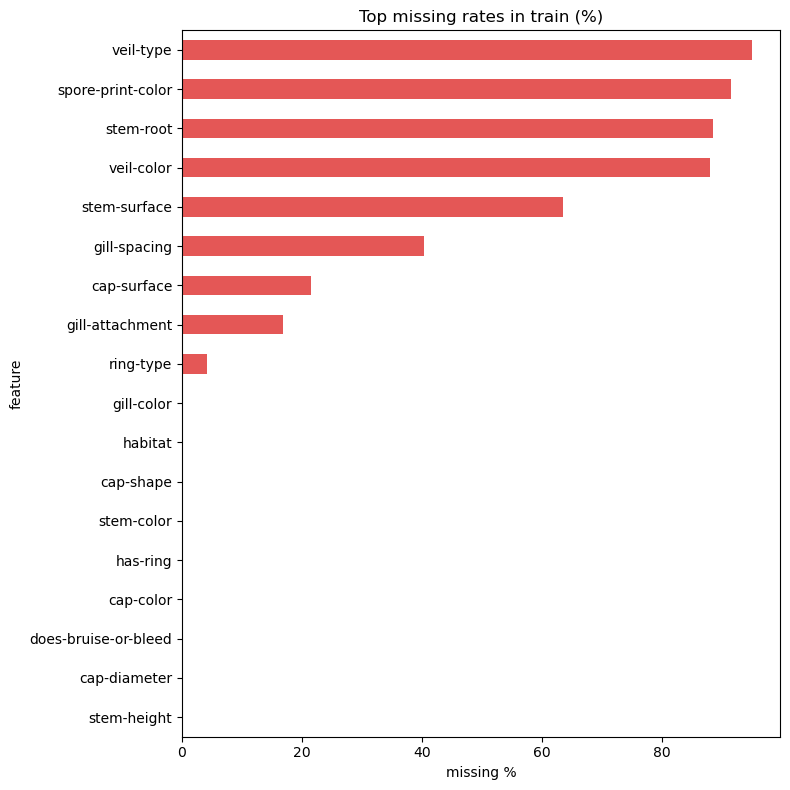

In [31]:
missing_train = train_df.isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df.isna().mean().mul(100).sort_values(ascending=False)

missing_report = pd.DataFrame(
    {
        "missing_pct_train": missing_train,
        "missing_pct_test": missing_test,
    }
).fillna(0.0)
missing_report["missing_diff_pp"] = missing_report["missing_pct_train"] - missing_report["missing_pct_test"]
missing_report = missing_report[["missing_pct_train", "missing_pct_test", "missing_diff_pp"]]

missing_non_zero = missing_report[(missing_report["missing_pct_train"] > 0) | (missing_report["missing_pct_test"] > 0)]
print(f"Columns with missing values: {len(missing_non_zero)}")
display(missing_non_zero.head(30))

if not missing_non_zero.empty:
    top_missing = missing_non_zero.sort_values("missing_pct_train", ascending=True).tail(25)
    ax = top_missing["missing_pct_train"].plot(kind="barh", figsize=(8, 8), color="#E45756")
    ax.set_title("Top missing rates in train (%)")
    ax.set_xlabel("missing %")
    ax.set_ylabel("feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in train/test.")

### Missing values and quality

Two key signals matter here:
- absolute missing rates per feature,
- similarity of missing rates between train and test.

If missingness is similar across train and test, preprocessing learned on train is more likely to transfer safely to test.

In [8]:
cat_cols = train_df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "class"]

rare_threshold = 0.005  # 0.5%
rare_rows = []

for col in cat_cols:
    freq = train_df[col].value_counts(normalize=True, dropna=False)
    rare = freq[freq < rare_threshold]
    rare_rows.append(
        {
            "column": col,
            "n_unique": train_df[col].nunique(dropna=True),
            "n_rare_categories": int(rare.shape[0]),
            "rare_total_pct": round(float(rare.sum() * 100), 3),
        }
    )

rare_summary = pd.DataFrame(rare_rows).sort_values(
    ["n_rare_categories", "rare_total_pct"], ascending=False
)
display(rare_summary.head(20))

,column,n_unique,n_rare_categories,rare_total_pct
1,cap-surface,83,72,0.019
4,gill-attachment,78,71,0.016
0,cap-shape,74,68,0.018
2,cap-color,78,67,0.012
8,stem-surface,60,53,0.029
6,gill-color,63,52,0.016
9,stem-color,59,50,0.585
15,habitat,52,46,0.185
5,gill-spacing,48,45,0.005
7,stem-root,38,34,0.025


This step identifies high-cardinality categorical features and quantifies how many levels are rare.

Why this matters:
- rare levels increase overfitting risk,
- they make one-hot encoding unstable,
- and they amplify train/test mismatch.

Grouping rare levels into one label is a regularization strategy for categorical variables.

## 4) Train vs Test Consistency Check

Questions to answer:
- Do train and test share the same columns and category space?
- Are there categories present in test but absent in train?


In [30]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

missing_in_test = sorted(train_cols - test_cols - {"class"})
extra_in_test = sorted(test_cols - train_cols)

print("Columns in train but not in test (excluding target):", missing_in_test)
print("Columns in test but not in train:", extra_in_test)

common_cat_cols = [
    c for c in train_df.select_dtypes(include=["object", "string"]).columns
    if c in test_df.columns and c != "class"
]

unseen_rows = []
for col in common_cat_cols:
    train_cats = set(train_df[col].dropna().unique())
    test_cats = set(test_df[col].dropna().unique())
    unseen_in_test = test_cats - train_cats
    unseen_rows.append(
        {
            "column": col,
            "train_unique": len(train_cats),
            "test_unique": len(test_cats),
            "unseen_in_test_count": len(unseen_in_test),
            "sample_unseen_in_test": ", ".join(list(sorted(unseen_in_test))[:5]) if unseen_in_test else "",
        }
    )

unseen_report = pd.DataFrame(unseen_rows).sort_values("unseen_in_test_count", ascending=False)
display(unseen_report.head(30))

n_problem_cols = (unseen_report["unseen_in_test_count"] > 0).sum()
print(f"Categorical columns with unseen categories in test: {n_problem_cols}")

Columns in train but not in test (excluding target): []
Columns in test but not in train: []


,column,train_unique,test_unique,unseen_in_test_count,sample_unseen_in_test
4,gill-attachment,78,66,39,"0.87, 0.88, 0.93, 0.95, 1.26"
0,cap-shape,74,62,34,"0.74, 0.93, 0.97, 1.25, 1.53"
1,cap-surface,83,59,31,"0.94, 1.95, 10.09, 11.96, 12.15"
2,cap-color,78,57,31,"0.73, 0.91, 1.83, 10.83, 10.93"
9,stem-color,59,55,29,"10.6, 10.93, 11.0, 11.31, 17.16"
8,stem-surface,60,54,27,"10.14, 11.53, 13.01, 13.09, 15.25"
6,gill-color,63,56,23,"1.55, 10.34, 10.56, 12.87, 17.26"
5,gill-spacing,48,35,18,"1.46, 1.61, 1.64, 1.68, 13.66"
15,habitat,52,39,13,"1.75, 19.85, 2.02, 2.53, 3.19"
14,spore-print-color,32,33,11,"17.72, 2.52, 2.92, 26.48, 27.48"


Categorical columns with unseen categories in test: 16


### Train vs test consistency

We verify:
- feature alignment between train and test,
- and unseen categories appearing only in test.

If unseen categories are frequent, our encoder must ignore unknown levels (or map them beforehand).

## 5) End-of-Analysis Summary

### Key findings
- The dataset is large: about 3.12M rows in train and 2.08M rows in test, which supports robust cross-validation.
- The target is mildly imbalanced (`p`: 54.71%, `e`: 45.29%; imbalance ratio ~1.21).
- Several features have very high missing rates (up to ~95%), especially `veil-type`, `spore-print-color`, `stem-root`, and `veil-color`.
- Missing-value rates are very similar in train and test, which reduces distribution-shift risk on this aspect.
- Many categorical features contain categories in test that are not present in train (16 columns affected), so encoding must safely handle unseen levels.

### Preprocessing strategy
- Keep rows and handle missing values explicitly (`MISSING` for categorical features, KNN imputation for numerical features).
- Use an encoding/modeling pipeline that is robust to unknown categories at inference time.


## Feature Treatment Plan

This table summarizes what to do with each feature before modeling. The key idea is to treat each column according to its statistical role, not all in the same way.

| Column | Type | Main issue | Recommended action | Encoder / Imputer | Why |
|---|---|---:|---|---|---|
| `id` | Identifier | Unique per row | Drop | None | It does not carry predictive information. |
| `class` | Target | Prediction label | Keep as target only | None | This is the label to predict. |
| `cap-diameter` | Numeric | No missing values, continuous values | Keep | KNN | Stable numeric feature, robust to outliers. |
| `stem-height` | Numeric | No missing values, continuous values | Keep | KNN | Stable numeric feature, robust to outliers. |
| `stem-width` | Numeric | No missing values, continuous values | Keep | KNN | Stable numeric feature, robust to outliers. |
| `season` | Categorical, low cardinality | Few categories | Keep | OneHotEncoder | Small number of levels, easy to encode. |
| `does-bruise-or-bleed` | Categorical, low cardinality | Binary / small cardinality | Keep | OneHotEncoder | Very compact and informative. |
| `has-ring` | Categorical, low cardinality | Binary / small cardinality | Keep | OneHotEncoder | Very compact and informative. |
| `cap-shape` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Prevents overfitting on tiny categories. |
| `cap-surface` | Categorical, high cardinality | Many missing/rare modalities | Keep and group rare levels | OneHotEncoder  | Useful signal, but too fragmented as-is. |
| `cap-color` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Color remains informative after rare grouping. |
| `gill-attachment` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Strong candidate for rare-category compression. |
| `gill-spacing` | Categorical, high cardinality | Many missing and rare modalities | Keep and group rare levels | OneHotEncoder | Missingness itself may be informative. |
| `gill-color` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | High-cardinality feature, do not drop blindly. |
| `stem-root` | Categorical, very high missing rate | Almost always missing | Keep in first baseline, test dropping in ablation | Missing -> `MISSING`, rare -> `RARE` | The missing pattern may carry signal. |
| `stem-surface` | Categorical, very high missing rate | Almost always missing | Keep in first baseline, test dropping in ablation | Missing -> `MISSING`, rare -> `RARE` | Sparse but possibly informative. |
| `stem-color` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Useful after rare-category grouping. |
| `veil-type` | Categorical, extremely high missing rate | Near-constant missingness | Keep only as an experiment | Missing -> `MISSING`, rare -> `RARE` | Often weak, but keep for a controlled comparison. |
| `veil-color` | Categorical, extremely high missing rate | Near-constant missingness | Keep only as an experiment | Missing -> `MISSING`, rare -> `RARE` | The missing pattern may be more useful than the raw value. |
| `ring-type` | Categorical, moderate cardinality | Some rare modalities | Keep and group rare levels | OneHotEncoder | Moderate cardinality, still informative. |
| `habitat` | Categorical, moderate cardinality | Rare categories exist | Keep and group rare levels | OneHotEncoder | Often useful biologically. |

### Practical interpretation
- `MISSING` means the value was absent in the original data.
- `RARE` means the value existed but was too infrequent to be trusted alone.
- The current pipeline in this notebook is: keep categorical missingness explicit, group rare categories, impute numerical values with KNN, then apply one-hot encoding.


## Data cleaning

In [20]:
train_df_cleaned = train_df.copy()
test_df_cleaned = test_df.copy()

### 1) Delete id column

In [21]:
train_df_cleaned = train_df_cleaned.drop(columns=['id'])
test_df_cleaned = test_df_cleaned.drop(columns=['id'])

print(train_df_cleaned.shape)
print(test_df_cleaned.shape)

(3116945, 21)
(2077964, 20)


### 2) Setup cleaning objects

In [ ]:

TARGET_COL = "class"
RARE_LABEL = "RARE"
MISSING_LABEL = "MISSING"
RARE_THRESHOLD = 0.005  # 0.5%

# Partir des copies déjà créées
# train_df_cleaned / test_df_cleaned
X_train = train_df_cleaned.drop(columns=[TARGET_COL], errors="ignore").copy()
y_train = train_df_cleaned[TARGET_COL].copy()
X_test = test_df_cleaned.copy()

# Colonnes catégorielles / numériques
categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Target:", TARGET_COL)
print("N categorical:", len(categorical_cols))
print("N numerical:", len(numerical_cols))
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Target: class
N categorical: 17
N numerical: 3
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']
Numerical columns: ['cap-diameter', 'stem-height', 'stem-width']


### 3) Group together rare categories

In [23]:
rare_maps = {}

for col in categorical_cols:
    freq = X_train[col].value_counts(normalize=True, dropna=True)
    rare_values = freq[freq < RARE_THRESHOLD].index
    rare_maps[col] = set(rare_values)

print("Example rare counts per column:")
display(
    pd.Series({c: len(v) for c, v in rare_maps.items()})
    .sort_values(ascending=False)
    .to_frame("n_rare_categories")
    .head(20)
)

Example rare counts per column:


,n_rare_categories
cap-surface,72
gill-attachment,71
cap-shape,67
cap-color,66
stem-surface,53
gill-color,51
stem-color,49
habitat,45
gill-spacing,45
stem-root,34


### 4) Apply mapping train/test + handle unknowns and NaN 

In [24]:
for col in categorical_cols:
    # Convertir en string pour éviter les surprises de dtype
    X_train[col] = X_train[col].astype("string")
    X_test[col] = X_test[col].astype("string")

    # NaN explicite
    X_train[col] = X_train[col].fillna(MISSING_LABEL)
    X_test[col] = X_test[col].fillna(MISSING_LABEL)

    # Regrouper les rares du train
    X_train[col] = X_train[col].where(~X_train[col].isin(rare_maps[col]), RARE_LABEL)

    # Côté test:
    # - valeurs rares connues -> RARE
    # - valeurs inconnues (pas vues dans train) -> RARE aussi
    known_train_values = set(X_train[col].unique())
    X_test[col] = X_test[col].where(X_test[col].isin(known_train_values), RARE_LABEL)

### 5) Numeric imputation

In [25]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
X_train[numerical_cols] = knn_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = knn_imputer.transform(X_test[numerical_cols])

### 6) Checks

In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Remaining NaN train:", int(X_train.isna().sum().sum()))
print("Remaining NaN test :", int(X_test.isna().sum().sum()))

# Vérifier rapidement cardinalité post-nettoyage
post_card = pd.Series({c: X_train[c].nunique(dropna=False) for c in categorical_cols}) \
    .sort_values(ascending=False) \
    .to_frame("n_unique_after_cleaning")
display(post_card.head(20))

X_train shape: (3116945, 20)
X_test shape : (2077964, 20)
Remaining NaN train: 0
Remaining NaN test : 0


,n_unique_after_cleaning
cap-color,14
gill-color,14
cap-surface,13
stem-color,12
cap-shape,9
stem-surface,9
spore-print-color,9
habitat,9
gill-attachment,9
ring-type,9


In [27]:
# Display the cleaned tables and a few useful summaries
display(X_train.head())
display(X_test.head())

print('Cleaned train info:')
display(pd.DataFrame({
    'rows': [X_train.shape[0]],
    'columns': [X_train.shape[1]],
    'missing_total': [int(X_train.isna().sum().sum())],
    'categorical_cols': [len(categorical_cols)],
    'numerical_cols': [len(numerical_cols)],
}))

print('Cleaned test info:')
display(pd.DataFrame({
    'rows': [X_test.shape[0]],
    'columns': [X_test.shape[1]],
    'missing_total': [int(X_test.isna().sum().sum())],
}))

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,8.80,f,s,u,f,a,c,w,4.51,15.39,MISSING,MISSING,w,MISSING,MISSING,f,f,MISSING,d,a
1,4.51,x,h,o,f,a,c,n,4.79,6.48,MISSING,y,o,MISSING,MISSING,t,z,MISSING,d,w
2,6.94,f,s,b,f,x,c,w,6.85,9.93,MISSING,s,n,MISSING,MISSING,f,f,MISSING,l,w
3,3.88,f,y,g,f,s,MISSING,g,4.16,6.53,MISSING,MISSING,w,MISSING,MISSING,f,f,MISSING,d,u
4,5.85,x,l,w,f,d,MISSING,w,3.37,8.36,MISSING,MISSING,w,MISSING,MISSING,f,f,MISSING,g,a


,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,8.64,x,MISSING,n,t,MISSING,MISSING,w,11.13,17.12,b,MISSING,w,u,w,t,g,MISSING,d,a
1,6.90,o,t,o,f,MISSING,c,y,1.27,10.75,MISSING,MISSING,n,MISSING,MISSING,f,f,MISSING,d,a
2,2.00,b,g,n,f,MISSING,c,n,6.18,3.14,MISSING,MISSING,n,MISSING,MISSING,f,f,MISSING,d,s
3,3.47,x,t,n,f,s,c,n,4.98,8.51,MISSING,MISSING,w,MISSING,n,t,z,MISSING,d,u
4,6.17,x,h,y,f,p,MISSING,y,6.73,13.70,MISSING,MISSING,y,MISSING,y,t,MISSING,MISSING,d,u


Cleaned train info:


,rows,columns,missing_total,categorical_cols,numerical_cols
0,3116945,20,0,17,3


Cleaned test info:


,rows,columns,missing_total
0,2077964,20,0


### 7) One-Hot Encoding (after cleaning)

At this stage, categorical features are cleaned (`MISSING` and `RARE` already handled), and numerical features are imputed.

We now apply One-Hot Encoding on categorical columns only, keep numerical columns as they are, and concatenate both into sparse matrices suitable for modeling on large datasets.

In [28]:
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse
import numpy as np

# One-hot encode categorical columns
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32
)

X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

# Keep numerical columns as sparse matrices
X_train_num = sparse.csr_matrix(X_train[numerical_cols].to_numpy(dtype=np.float32))
X_test_num = sparse.csr_matrix(X_test[numerical_cols].to_numpy(dtype=np.float32))

# Final design matrices for modeling
X_train_final = sparse.hstack([X_train_num, X_train_cat], format="csr")
X_test_final = sparse.hstack([X_test_num, X_test_cat], format="csr")

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape :", X_test_final.shape)
print("Train nnz:", X_train_final.nnz)
print("Test nnz :", X_test_final.nnz)

# Quick feature-name check
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + ohe_feature_names.tolist()
print("Total encoded feature count:", len(all_feature_names))
print("First 20 feature names:")
print(all_feature_names[:20])

X_train_final shape: (3116945, 144)
X_test_final shape : (2077964, 144)
Train nnz: 62337849
Test nnz : 41558621
Total encoded feature count: 144
First 20 feature names:
['cap-diameter', 'stem-height', 'stem-width', 'cap-shape_MISSING', 'cap-shape_RARE', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f', 'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x', 'cap-surface_MISSING', 'cap-surface_RARE', 'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h', 'cap-surface_i', 'cap-surface_k']


### Reading guide - One-hot encoded matrices

After encoding, always verify:
- final matrix dimensions,
- sparsity (nnz) to estimate memory usage,
- and feature name expansion.

A very large feature count is normal with one-hot encoding on high-cardinality columns; sparsity keeps computation tractable.

max_iter reached after 458 seconds


c:\Users\Antoine\anaconda3\envs\ds52_td2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


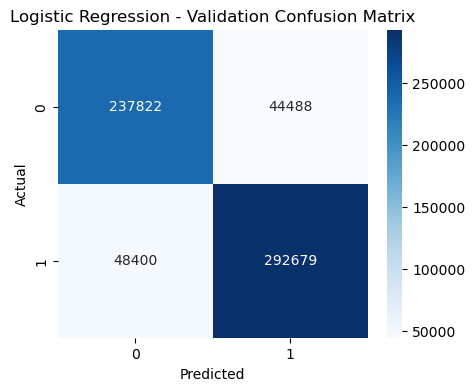

              precision    recall  f1-score   support

           e       0.83      0.84      0.84    282310
           p       0.87      0.86      0.86    341079

    accuracy                           0.85    623389
   macro avg       0.85      0.85      0.85    623389
weighted avg       0.85      0.85      0.85    623389

MCC: 0.6997
ROC-AUC: 0.9267


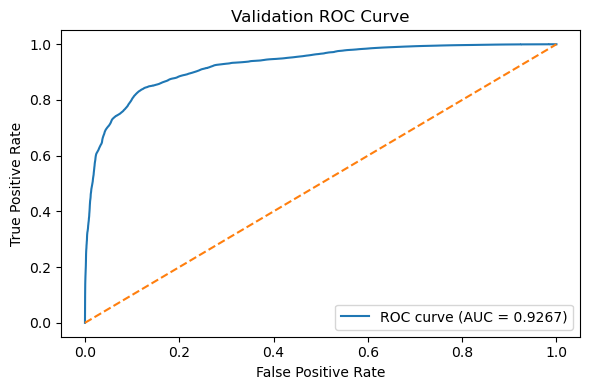

,id,class
0,3116945,e
1,3116946,p
2,3116947,p
3,3116948,p
4,3116949,e


In [ ]:
# Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef
)

# Split train into train/validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Train model
model = LogisticRegression(max_iter=200, solver="saga", verbose=1)
model.fit(X_tr, y_tr)

# Validation predictions
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification metrics
print(classification_report(y_val, y_pred))
print(f"MCC: {matthews_corrcoef(y_val, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_val, y_proba):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Kaggle predictions (for submission)
test_pred = model.predict(X_test_final)
submission = pd.DataFrame({
    "id": test_df["id"],
    "class": test_pred
})
submission.head()